In [1]:
!pip install kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:19<00:00, 17.6MB/s]



In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import os


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


data_dir = 'chest_xray'
batch_size = 32

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {
    'train': datasets.ImageFolder(os.path.join(data_dir, 'train'), data_transforms['train']),
    'val': datasets.ImageFolder(os.path.join(data_dir, 'val'), data_transforms['val'])
}

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=batch_size, shuffle=True),
    'val': DataLoader(image_datasets['val'], batch_size=batch_size, shuffle=False)
}


model = models.resnet50(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

num_epochs = 3

for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    print('-' * 10)

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(image_datasets[phase])
        epoch_acc = running_corrects.double() / len(image_datasets[phase])

        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

torch.save(model.state_dict(), 'resnet50_pneumonia_baseline.pth')
print("Model saved as resnet50_pneumonia_baseline.pth")

Using device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 209MB/s]


Epoch 1/3
----------
train Loss: 0.2626 Acc: 0.8907
val Loss: 0.3887 Acc: 0.7500
Epoch 2/3
----------
train Loss: 0.1547 Acc: 0.9363
val Loss: 0.3454 Acc: 0.8125
Epoch 3/3
----------
train Loss: 0.1570 Acc: 0.9417
val Loss: 0.1187 Acc: 1.0000
Model saved as resnet50_pneumonia_baseline.pth


In [1]:
!pip install captum

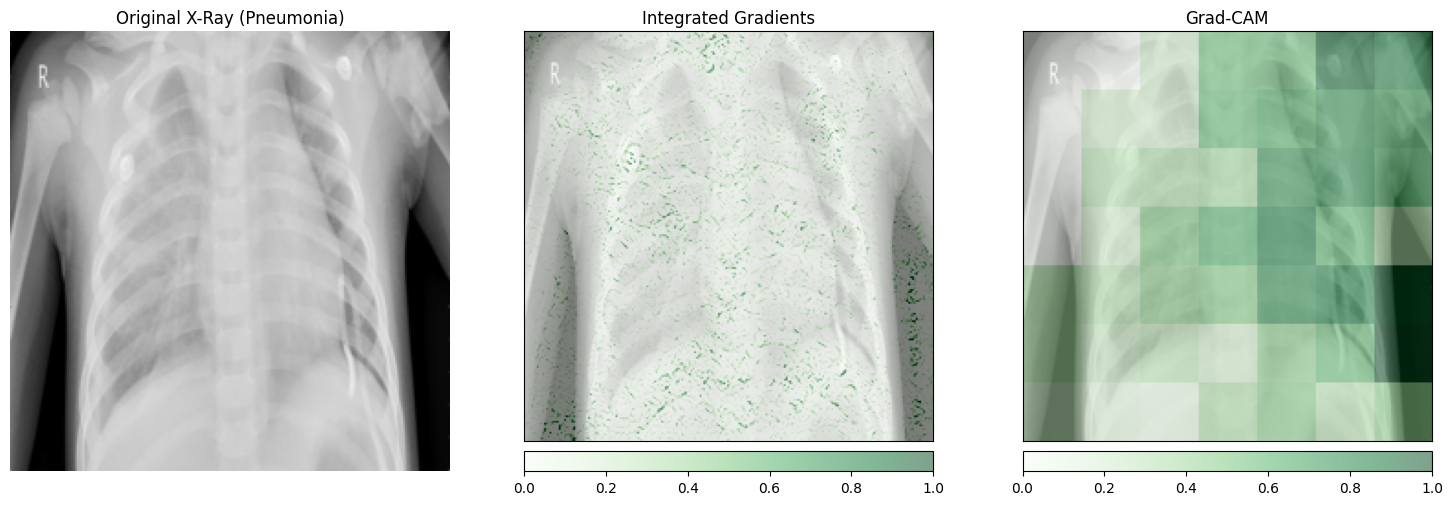

In [4]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os

from captum.attr import IntegratedGradients, LayerGradCam, LayerAttribution
from captum.attr import visualization as viz

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(pretrained=False) # False because we are loading your weights
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)
model.load_state_dict(torch.load('resnet50_pneumonia_baseline.pth'))
model = model.to(device)
model.eval()


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


img_path = os.path.join('chest_xray', 'train', 'PNEUMONIA')
sample_image_name = os.listdir(img_path)[0]
image = Image.open(os.path.join(img_path, sample_image_name)).convert('RGB')

input_tensor = transform(image).unsqueeze(0).to(device)
input_tensor.requires_grad_()

ig = IntegratedGradients(model)
layer_gc = LayerGradCam(model, model.layer4[-1])

# 5. Calculate Attributions (Target 1 = Pneumonia)
ig_attr = ig.attribute(input_tensor, target=1, n_steps=50)
gc_attr = layer_gc.attribute(input_tensor, target=1)

upsampled_gc_attr = LayerAttribution.interpolate(gc_attr, input_tensor.shape[2:])

original_image = np.transpose((input_tensor.squeeze().cpu().detach().numpy() * np.array([0.229, 0.224, 0.225]).reshape(3,1,1) +
                              np.array([0.485, 0.456, 0.406]).reshape(3,1,1)), (1,2,0))
original_image = np.clip(original_image, 0, 1)

ig_attr_np = np.transpose(ig_attr.squeeze().cpu().detach().numpy(), (1,2,0))

gc_attr_np = upsampled_gc_attr.squeeze().cpu().detach().numpy()
gc_attr_np = np.expand_dims(gc_attr_np, axis=2)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(original_image)
axs[0].set_title("Original X-Ray (Pneumonia)")
axs[0].axis('off')

viz.visualize_image_attr(ig_attr_np, original_image, method="blended_heat_map",
                         sign="positive", show_colorbar=True,
                         title="Integrated Gradients", plt_fig_axis=(fig, axs[1]), use_pyplot=False)

viz.visualize_image_attr(gc_attr_np, original_image, method="blended_heat_map",
                         sign="positive", show_colorbar=True,
                         title="Grad-CAM", plt_fig_axis=(fig, axs[2]), use_pyplot=False)

plt.tight_layout()
plt.show()

Running Faithfulness Evaluation (This takes a few seconds...)


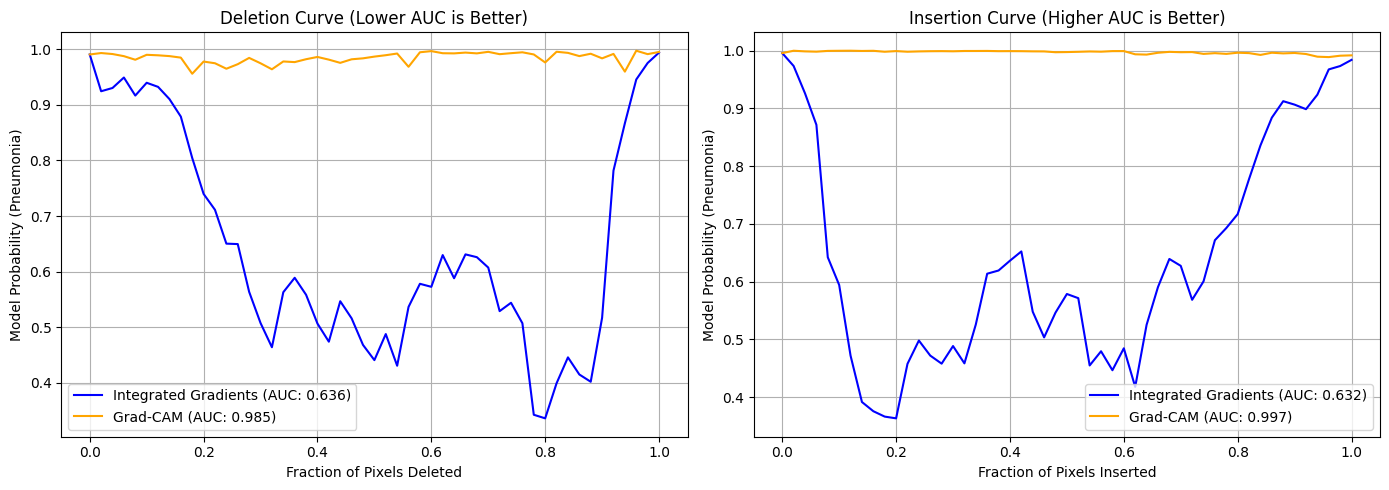

--- FINAL METRICS ---
Integrated Gradients - Deletion AUC: 0.636 | Insertion AUC: 0.632
Grad-CAM           - Deletion AUC: 0.985 | Insertion AUC: 0.997


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import auc
import torch

def calculate_faithfulness(model, image_tensor, attr_map, target_class=1, steps=50):
    model.eval()


    if attr_map.dim() == 4 and attr_map.shape[1] == 3:
        spatial_attr = torch.sum(attr_map, dim=1).squeeze().cpu().detach().numpy()
    else:
        spatial_attr = attr_map.squeeze().cpu().detach().numpy()


    h, w = spatial_attr.shape
    total_pixels = h * w
    flat_indices = np.argsort(spatial_attr.flatten())[::-1]

    deletion_scores = []
    insertion_scores = []


    baseline = torch.zeros_like(image_tensor)


    with torch.no_grad():
        orig_prob = torch.softmax(model(image_tensor), dim=1)[0, target_class].item()


    step_size = total_pixels // steps

    for i in range(steps + 1):
        num_pixels = min(i * step_size, total_pixels)


        mask = np.zeros(total_pixels)
        mask[flat_indices[:num_pixels]] = 1.0
        mask = mask.reshape((1, 1, h, w))
        mask_tensor = torch.tensor(mask, dtype=torch.float32, device=device)


        del_img = image_tensor * (1 - mask_tensor)


        ins_img = baseline * (1 - mask_tensor) + image_tensor * mask_tensor

        with torch.no_grad():
            del_prob = torch.softmax(model(del_img), dim=1)[0, target_class].item()
            ins_prob = torch.softmax(model(ins_img), dim=1)[0, target_class].item()

        deletion_scores.append(del_prob)
        insertion_scores.append(ins_prob)


    x_axis = np.linspace(0, 1, steps + 1)
    del_auc = auc(x_axis, deletion_scores)
    ins_auc = auc(x_axis, insertion_scores)

    return x_axis, deletion_scores, insertion_scores, del_auc, ins_auc

print("Running Faithfulness Evaluation (This takes a few seconds...)")
x_ig, del_ig, ins_ig, del_auc_ig, ins_auc_ig = calculate_faithfulness(model, input_tensor, ig_attr)
x_gc, del_gc, ins_gc, del_auc_gc, ins_auc_gc = calculate_faithfulness(model, input_tensor, upsampled_gc_attr)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(x_ig, del_ig, label=f'Integrated Gradients (AUC: {del_auc_ig:.3f})', color='blue')
axs[0].plot(x_gc, del_gc, label=f'Grad-CAM (AUC: {del_auc_gc:.3f})', color='orange')
axs[0].set_title('Deletion Curve (Lower AUC is Better)')
axs[0].set_xlabel('Fraction of Pixels Deleted')
axs[0].set_ylabel('Model Probability (Pneumonia)')
axs[0].legend()
axs[0].grid(True)


axs[1].plot(x_ig, ins_ig, label=f'Integrated Gradients (AUC: {ins_auc_ig:.3f})', color='blue')
axs[1].plot(x_gc, ins_gc, label=f'Grad-CAM (AUC: {ins_auc_gc:.3f})', color='orange')
axs[1].set_title('Insertion Curve (Higher AUC is Better)')
axs[1].set_xlabel('Fraction of Pixels Inserted')
axs[1].set_ylabel('Model Probability (Pneumonia)')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

print(f"--- FINAL METRICS ---")
print(f"Integrated Gradients - Deletion AUC: {del_auc_ig:.3f} | Insertion AUC: {ins_auc_ig:.3f}")
print(f"Grad-CAM           - Deletion AUC: {del_auc_gc:.3f} | Insertion AUC: {ins_auc_gc:.3f}")

Creating corrupted models for Sanity Checks...
Extracting heatmaps from corrupted brains...


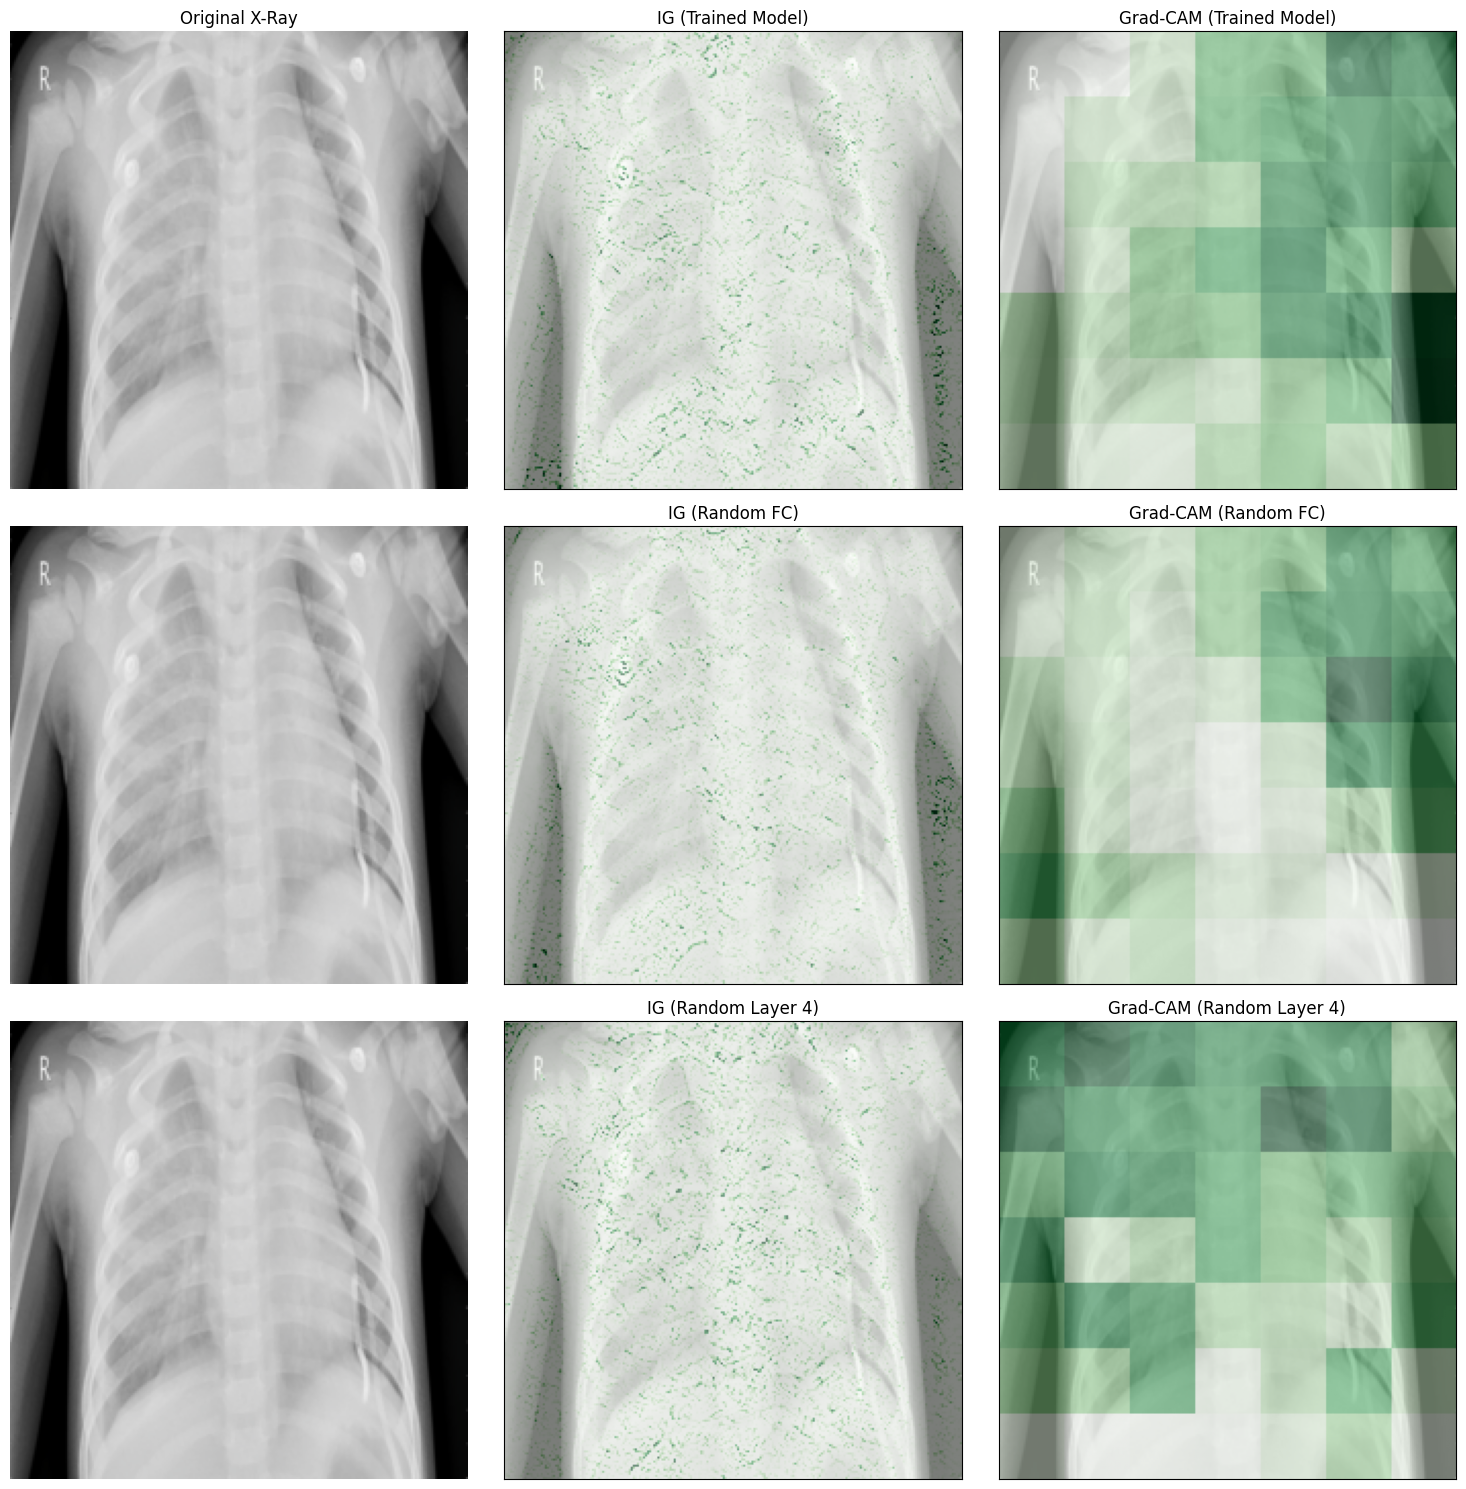

In [6]:
import torch
import torch.nn as nn
import copy
import matplotlib.pyplot as plt
from captum.attr import IntegratedGradients, LayerGradCam, LayerAttribution
from captum.attr import visualization as viz
import numpy as np

def randomize_weights(layer):
    if hasattr(layer, 'weight') and layer.weight is not None:
        if len(layer.weight.shape) >= 2:
            nn.init.xavier_uniform_(layer.weight)
        else:
            nn.init.uniform_(layer.weight)
    if hasattr(layer, 'bias') and layer.bias is not None:
        nn.init.zeros_(layer.bias)

print("Creating corrupted models for Sanity Checks...")
model_orig = copy.deepcopy(model)
model_orig.eval()

model_rand_fc = copy.deepcopy(model_orig)
randomize_weights(model_rand_fc.fc)
model_rand_fc.eval()

model_rand_layer4 = copy.deepcopy(model_rand_fc)
for module in model_rand_layer4.layer4.modules():
    randomize_weights(module)
model_rand_layer4.eval()

def get_heatmaps(m):
    ig = IntegratedGradients(m)
    layer_gc = LayerGradCam(m, m.layer4[-1])

    ig_attr = ig.attribute(input_tensor, target=1, n_steps=50)
    gc_attr = layer_gc.attribute(input_tensor, target=1)
    upsampled_gc = LayerAttribution.interpolate(gc_attr, input_tensor.shape[2:])

    ig_np = np.transpose(ig_attr.squeeze().cpu().detach().numpy(), (1,2,0))
    gc_np = np.expand_dims(upsampled_gc.squeeze().cpu().detach().numpy(), axis=2)
    return ig_np, gc_np

print("Extracting heatmaps from corrupted brains...")
ig_orig, gc_orig = get_heatmaps(model_orig)
ig_fc, gc_fc = get_heatmaps(model_rand_fc)
ig_l4, gc_l4 = get_heatmaps(model_rand_layer4)

fig, axs = plt.subplots(3, 3, figsize=(15, 15))

axs[0, 0].imshow(original_image)
axs[0, 0].set_title("Original X-Ray")
axs[0, 0].axis('off')
axs[1, 0].imshow(original_image)
axs[1, 0].axis('off')
axs[2, 0].imshow(original_image)
axs[2, 0].axis('off')

viz.visualize_image_attr(ig_orig, original_image, method="blended_heat_map", sign="positive",
                         title="IG (Trained Model)", plt_fig_axis=(fig, axs[0, 1]), use_pyplot=False)
viz.visualize_image_attr(gc_orig, original_image, method="blended_heat_map", sign="positive",
                         title="Grad-CAM (Trained Model)", plt_fig_axis=(fig, axs[0, 2]), use_pyplot=False)

viz.visualize_image_attr(ig_fc, original_image, method="blended_heat_map", sign="positive",
                         title="IG (Random FC)", plt_fig_axis=(fig, axs[1, 1]), use_pyplot=False)
viz.visualize_image_attr(gc_fc, original_image, method="blended_heat_map", sign="positive",
                         title="Grad-CAM (Random FC)", plt_fig_axis=(fig, axs[1, 2]), use_pyplot=False)

viz.visualize_image_attr(ig_l4, original_image, method="blended_heat_map", sign="positive",
                         title="IG (Random Layer 4)", plt_fig_axis=(fig, axs[2, 1]), use_pyplot=False)
viz.visualize_image_attr(gc_l4, original_image, method="blended_heat_map", sign="positive",
                         title="Grad-CAM (Random Layer 4)", plt_fig_axis=(fig, axs[2, 2]), use_pyplot=False)

plt.tight_layout()
plt.show()